In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = "../data/processed/final_dataset.csv"

df = pd.read_csv(file_path)

df.head()

,country,year,ev_sales_share,ev_stock,ev_stock_share,charging_points
0,Australia,2011,0.0061,49.0,0.00039,480.0
1,Australia,2012,0.0290,300.0,0.00240,480.0
2,Australia,2013,0.0330,590.0,0.00460,480.0
3,Australia,2014,0.1500,1880.0,0.01400,480.0
4,Australia,2015,0.1900,3600.0,0.02700,480.0


Distribution of target variable

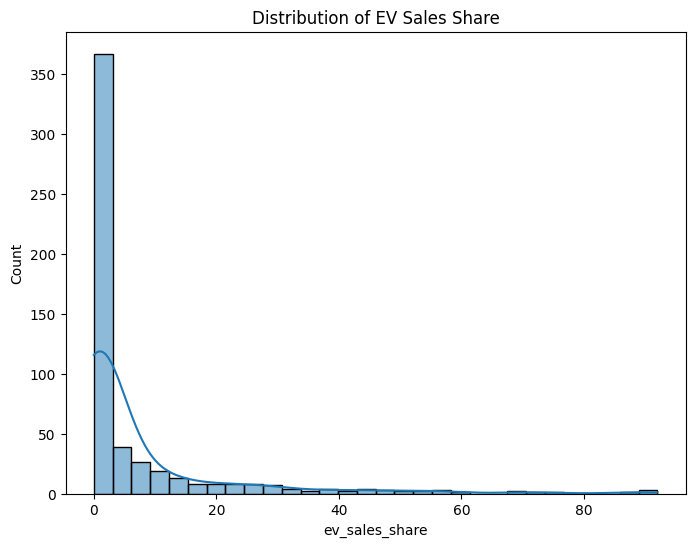

In [ ]:
plt.figure(figsize=(8,6))

sns.histplot(
    df['ev_sales_share'],
    bins=30,
    kde=True
)

plt.title('Distribution of EV Sales Share')

plt.show()

EV Sales Share is positively skewed, indicating that most countries have relatively low adoption while a smaller number have very high adoption.

Global EV Adoption Trend

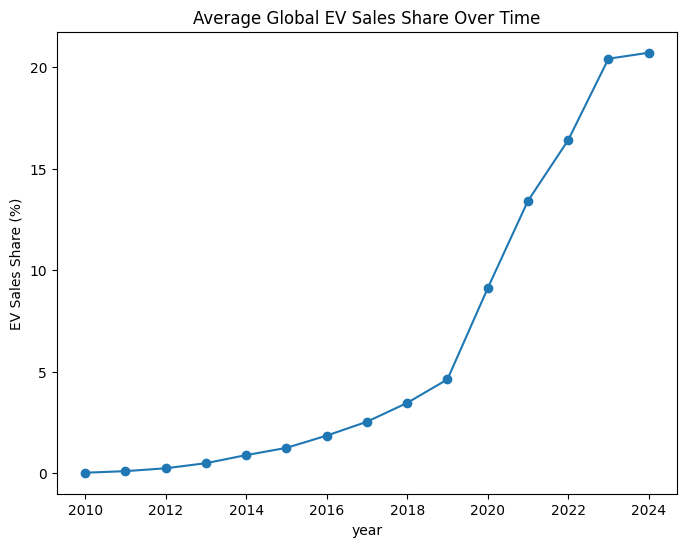

In [ ]:
global_trend = (
    df.groupby('year')
    ['ev_sales_share']
    .mean()
)

global_trend.plot(
    marker='o',
    figsize=(8,6)
)

plt.title(
    'Average Global EV Sales Share Over Time'
)

plt.ylabel('EV Sales Share (%)')

plt.show()

The average EV Sales Share has increased steadily over time, suggesting continuous global growth in electric vehicle adoption.

Top 20 Countries

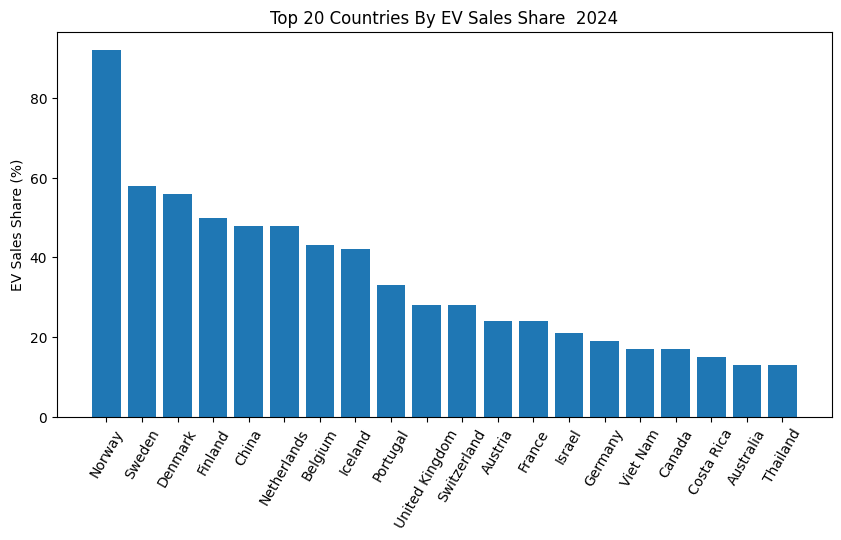

In [ ]:
latest_year = df["year"].max()

latest = df[df["year"] == latest_year]

top20 = (
    latest
    .sort_values(
        "ev_sales_share",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(10,5))
plt.bar(top20["country"], top20["ev_sales_share"])
plt.xticks(rotation=60)
plt.title(f'Top 20 Countries By EV Sales Share  {latest_year}')
plt.ylabel("EV Sales Share (%)")
plt.show()

EV Stock Share vs EV Sales Share

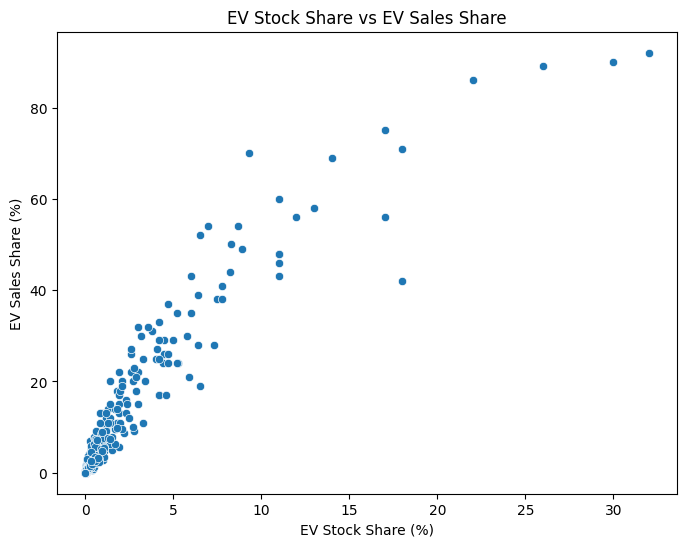

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='ev_stock_share',
    y='ev_sales_share'
)

plt.title('EV Stock Share vs EV Sales Share')
plt.xlabel('EV Stock Share (%)')
plt.ylabel('EV Sales Share (%)')

plt.show()

A strong positive relationship is observed between EV Stock Share and EV Sales Share, indicating that countries with higher EV penetration tend to have higher EV sales.

In [3]:
corr_matrix = df[
    ['ev_sales_share',
     'ev_stock',
     'ev_stock_share',
     'charging_points']
].corr()

corr_matrix

,ev_sales_share,ev_stock,ev_stock_share,charging_points
ev_sales_share,1.000000,0.232293,0.935413,0.201970
ev_stock,0.232293,1.000000,0.219649,0.974295
ev_stock_share,0.935413,0.219649,1.000000,0.186947
charging_points,0.201970,0.974295,0.186947,1.000000


Correlation Heatmap

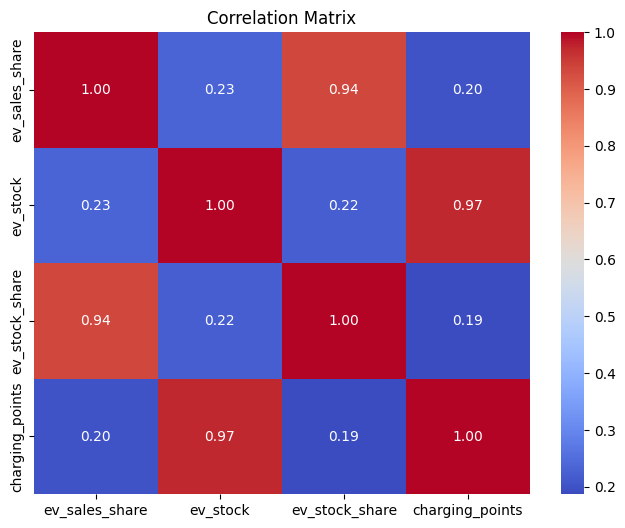

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

EV Stock Share exhibits the strongest positive correlation with EV Sales Share, while EV Stock and Charging Points show comparatively weaker direct correlations.